In [1]:
# ============================================
# 1. IMPORT LIBRARIES
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.naive_bayes import GaussianNB

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    balanced_accuracy_score
)

In [2]:
# ============================================
# 2. CREATE DATASET
# ============================================

df=pd.read_csv(r"C:\Users\Admin\Downloads\archive\Loan_Default_1.csv")
df.head()
df.isnull().sum()

ID                               0
year                             0
loan_limit                    3344
Gender                           0
approv_in_adv                  908
loan_type                        0
loan_purpose                   134
Credit_Worthiness                0
open_credit                      0
business_or_commercial           0
loan_amount                      0
rate_of_interest             36439
Interest_rate_spread         36639
Upfront_charges              39642
term                            41
Neg_ammortization              121
interest_only                    0
lump_sum_payment                 0
property_value               15098
construction_type                0
occupancy_type                   0
Secured_by                       0
total_units                      0
income                        9150
credit_type                      0
Credit_Score                     0
co-applicant_credit_type         0
age                            200
submission_of_applic

In [3]:
# ============================================
# 3. BASIC EDA
# ============================================

print("Shape:")
print(df.shape)

print("\nColumns:")
print(df.columns)

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Values:")
print(df.duplicated().sum())

print("\nStatistics:")
print(df.describe())

Shape:
(148670, 34)

Columns:
Index(['ID', 'year', 'loan_limit', 'Gender', 'approv_in_adv', 'loan_type',
       'loan_purpose', 'Credit_Worthiness', 'open_credit',
       'business_or_commercial', 'loan_amount', 'rate_of_interest',
       'Interest_rate_spread', 'Upfront_charges', 'term', 'Neg_ammortization',
       'interest_only', 'lump_sum_payment', 'property_value',
       'construction_type', 'occupancy_type', 'Secured_by', 'total_units',
       'income', 'credit_type', 'Credit_Score', 'co-applicant_credit_type',
       'age', 'submission_of_application', 'LTV', 'Region', 'Security_Type',
       'Status', 'dtir1'],
      dtype='object')

Data Types:
ID                             int64
year                           int64
loan_limit                    object
Gender                        object
approv_in_adv                 object
loan_type                     object
loan_purpose                  object
Credit_Worthiness             object
open_credit                   object
busi

In [4]:
# ============================================
# # 4. TARGET DISTRIBUTION
# # ============================================

# print(df["Buy"].value_counts())

# df["Buy"].value_counts().plot(kind="bar")

# plt.xlabel("Class")
# plt.ylabel("Count")
# plt.title("Target Distribution")
# plt.show()

In [5]:
# ============================================
# 5. X AND y
# ============================================
X=df.drop(columns=[ "ID"])
# y=df["status"]
print("X:")
print(X.head())

# print("\ny:")
# print(y.head())

X:
   year loan_limit             Gender approv_in_adv loan_type loan_purpose  \
0  2019         cf  Sex Not Available         nopre     type1           p1   
1  2019         cf               Male         nopre     type2           p1   
2  2019         cf               Male           pre     type1           p1   
3  2019         cf               Male         nopre     type1           p4   
4  2019         cf              Joint           pre     type1           p1   

  Credit_Worthiness open_credit business_or_commercial  loan_amount  ...  \
0                l1        nopc                  nob/c       116500  ...   
1                l1        nopc                    b/c       206500  ...   
2                l1        nopc                  nob/c       406500  ...   
3                l1        nopc                  nob/c       456500  ...   
4                l1        nopc                  nob/c       696500  ...   

   credit_type  Credit_Score  co-applicant_credit_type    age  \
0     

In [6]:
X=df.drop(columns=["Status"])
y=df["Status"]

In [7]:
# ============================================
# 6. TRAIN TEST SPLIT
# ============================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

numeric_features = X_train.select_dtypes(include=["number"]).columns
categorical_features = X_train.select_dtypes(exclude=["number"]).columns

preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            SimpleImputer(strategy="median"),
            numeric_features
        ),
        (
            "categorical",
            Pipeline([
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
            ]),
            categorical_features
        )
    ]
)

X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print("X_train:", X_train_processed.shape)
print("X_test :", X_test_processed.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (118936, 71)
X_test : (29734, 71)
y_train: (118936,)
y_test : (29734,)


In [8]:
# ============================================
# 7. GAUSSIAN NAIVE BAYES
# ============================================

model = GaussianNB()

model.fit(X_train_processed, y_train)

,"priors priors: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
,"var_smoothing var_smoothing: float, default=1e-9Portion of the largest variance of all features that is added tovariances for calculation stability... versionadded:: 0.20",1e-09
Name,Type,Value
"class_count_ class_count_: ndarray of shape (n_classes,)number of training samples observed in each class.","ndarray[float64](2,)","[89625.,29311.]"
"class_prior_ class_prior_: ndarray of shape (n_classes,)probability of each class.","ndarray[float64](2,)","[0.75,0.25]"
"classes_ classes_: ndarray of shape (n_classes,)class labels known to the classifier.","ndarray[int64](2,)","[0,1]"
epsilon_ epsilon_: floatabsolute additive value to variances.,float64,116.3
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,71
"theta_ theta_: ndarray of shape (n_classes, n_features)mean of each feature per class.","ndarray[float64](2, 71)","[[ 99248.97, 2019. ,335089.68,..., 0.42, 0. , 1. ], [ 99232.12, 2019. ,318452.51,..., 0.47, 0. , 1. ]]"
"var_ var_: ndarray of shape (n_classes, n_features)Variance of each feature per class... versionadded:: 1.0","ndarray[float64](2, 71)","[[1.84e+09,1.16e+02,3.06e+10,...,1.17e+02,1.16e+02,1.16e+02], [1.84e+09,1.16e+02,4.24e+10,...,1.17e+02,1.16e+02,1.16e+02]]"


In [9]:
# ============================================
# 8. PREDICTION
# ============================================

y_pred = model.predict(X_test_processed)

print("Predictions:")
print(y_pred)

Predictions:
[0 1 0 ... 0 0 0]


In [10]:
# ============================================
# 9. ACCURACY
# ============================================

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.9254388915046747


In [11]:
# ============================================
# 10. CONFUSION MATRIX
# ============================================

cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[20263  2143]
 [   74  7254]]


In [12]:
# ============================================
# 11. CLASSIFICATION REPORT
# ============================================

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      0.90      0.95     22406
           1       0.77      0.99      0.87      7328

    accuracy                           0.93     29734
   macro avg       0.88      0.95      0.91     29734
weighted avg       0.94      0.93      0.93     29734



In [13]:
# ============================================
# 12. BALANCED ACCURACY
# ============================================

balanced_acc = balanced_accuracy_score(y_test, y_pred)

print("Balanced Accuracy:", balanced_acc)

Balanced Accuracy: 0.9471288614013635


In [14]:
# ============================================
# 13. PREDICT PROBABILITY
# ============================================

y_probability = model.predict_proba(X_test_processed)

print(y_probability)

[[1.00000000e+000 1.04204083e-043]
 [1.17224881e-001 8.82775119e-001]
 [1.00000000e+000 0.00000000e+000]
 ...
 [1.00000000e+000 3.13716700e-078]
 [1.00000000e+000 1.22463562e-074]
 [1.00000000e+000 8.74561326e-134]]


In [15]:
# ============================================
# 14. GRID SEARCH
# ============================================

param_grid = {
    "var_smoothing": [
        1e-11,
        1e-10,
        1e-9,
        1e-8,
        1e-7,
        1e-6,
        1e-5
    ]
}

grid = GridSearchCV(
    estimator=GaussianNB(),
    param_grid=param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

grid.fit(X_train_processed, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",GaussianNB()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'var_smoothing': [1e-11, 1e-10, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting, with highe

In [16]:
# ============================================
# 15. BEST PARAMETERS
# ============================================

print("Best Parameters:")
print(grid.best_params_)

print("\nBest CV Score:")
print(grid.best_score_)

Best Parameters:
{'var_smoothing': 1e-11}

Best CV Score:
0.9286423019233199


In [17]:
# ============================================
# 16. BEST MODEL
# ============================================

best_model = grid.best_estimator_

print(best_model)

GaussianNB(var_smoothing=1e-11)


In [18]:
# ============================================
# 17. FINAL PREDICTION
# ============================================

y_pred_best = best_model.predict(X_test_processed)

print(y_pred_best)

[0 1 0 ... 0 0 0]


In [19]:
# ============================================
# 18. FINAL ACCURACY
# ============================================

final_accuracy = accuracy_score(y_test, y_pred_best)

print("Final Accuracy:", final_accuracy)

Final Accuracy: 0.9275240465460416


In [20]:
# ============================================
# 19. FINAL CONFUSION MATRIX
# ============================================

final_cm = confusion_matrix(y_test, y_pred_best)

print("Final Confusion Matrix:")
print(final_cm)

Final Confusion Matrix:
[[20350  2056]
 [   99  7229]]


In [21]:
# ============================================
# 20. FINAL CLASSIFICATION REPORT
# ============================================

print(
    classification_report(
        y_test,
        y_pred_best
    )
)

              precision    recall  f1-score   support

           0       1.00      0.91      0.95     22406
           1       0.78      0.99      0.87      7328

    accuracy                           0.93     29734
   macro avg       0.89      0.95      0.91     29734
weighted avg       0.94      0.93      0.93     29734



In [22]:
# ============================================
# 21. FINAL BALANCED ACCURACY
# ============================================

final_balanced_accuracy = balanced_accuracy_score(
    y_test,
    y_pred_best
)

print("Final Balanced Accuracy:",
      final_balanced_accuracy)

Final Balanced Accuracy: 0.9473645196311655


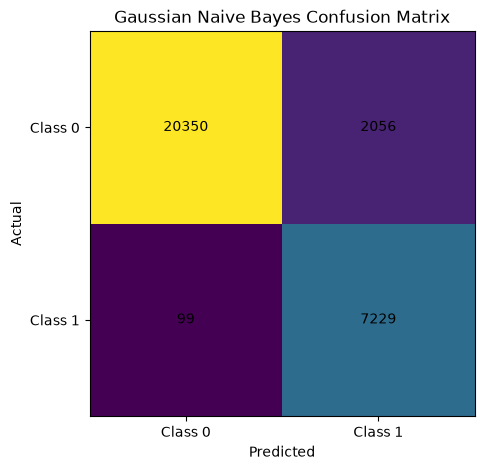

In [23]:
# ============================================
# 22. CONFUSION MATRIX VISUALIZATION
# ============================================

plt.figure(figsize=(6, 5))

plt.imshow(final_cm)

plt.title("Gaussian Naive Bayes Confusion Matrix")

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.xticks([0, 1], ["Class 0", "Class 1"])
plt.yticks([0, 1], ["Class 0", "Class 1"])

for i in range(2):
    for j in range(2):
        plt.text(j, i, final_cm[i, j],
                 ha="center",
                 va="center")

plt.show()

In [24]:
import gradio as gr
import pandas as pd

def predict_default(*values):
    try:
        # User input ko DataFrame mein convert karo
        input_data = pd.DataFrame(
            [values],
            columns=X.columns
        )

        # Same preprocessing used during training
        input_processed = preprocessor.transform(input_data)

        # Prediction
        prediction = model.predict(input_processed)[0]

        # Result
        if prediction == 1:
            return "⚠️ HIGH RISK — Loan Default"
        else:
            return "✅ LOW RISK — No Loan Default"

    except Exception as e:
        return f"Error: {e}"


# ============================================
# CREATE GRADIO INPUTS AUTOMATICALLY
# ============================================

inputs = []

for column in X.columns:

    if column in categorical_features:

        choices = sorted(
            X[column]
            .dropna()
            .astype(str)
            .unique()
            .tolist()
        )

        inputs.append(
            gr.Dropdown(
                choices=choices,
                label=column
            )
        )

    else:

        inputs.append(
            gr.Number(
                label=column
            )
        )


# ============================================
# GRADIO INTERFACE
# ============================================

demo = gr.Interface(
    fn=predict_default,
    inputs=inputs,
    outputs=gr.Textbox(
        label="Prediction"
    ),
    title="🏦 Loan Default Prediction",
    description="Gaussian Naive Bayes — Loan Default Prediction",
    theme=gr.themes.Soft()
)

demo.launch()

c:\Users\Admin\AppData\Local\Programs\Python\Python314\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
c:\Users\Admin\AppData\Local\Programs\Python\Python314\Lib\site-packages\gradio\interface.py:171: UserWarning: The parameters have been moved from the Blocks constructor to the launch() method in Gradio 6.0: theme. Please pass these parameters to launch() instead.
  super().__init__(


* Running on local URL:  http://127.0.0.1:7860
* To create a public link, set `share=True` in `launch()`.
